# Fraud Transaction Detection

Compares seven classifiers to predict `Fraud_Label` on a synthetic transaction dataset. Central finding: two raw features (`Risk_Score`, `Failed_Transaction_Count_7d`) turn out to near-perfectly reconstruct the label, so every model is trained and evaluated **twice**: once on the full ("naive") feature set and once with those two features removed ("leakage-aware"), to separate genuine model skill from a shortcut baked into the data. `class_weight='balanced'` is applied where supported, both ROC-AUC and PR-AUC (average precision) are reported throughout, and a cost-sensitive threshold analysis is run on **both** pipelines so the naive pipeline's dollar figure can be checked against a model that never had access to the leak, followed by SHAP-based explainability on both.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set(style="whitegrid")
RANDOM_STATE = 42

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data

In [2]:
df = pd.read_csv("fraud_transactions.csv")
print("Shape:", df.shape)
print("Missing values:", df.isna().sum().sum(), "total")   # dataset has none
print("Fraud rate:", df['Fraud_Label'].mean().round(4))

Shape: (50000, 21)
Missing values: 0 total
Fraud rate: 0.3213


## 2. Exploratory data analysis

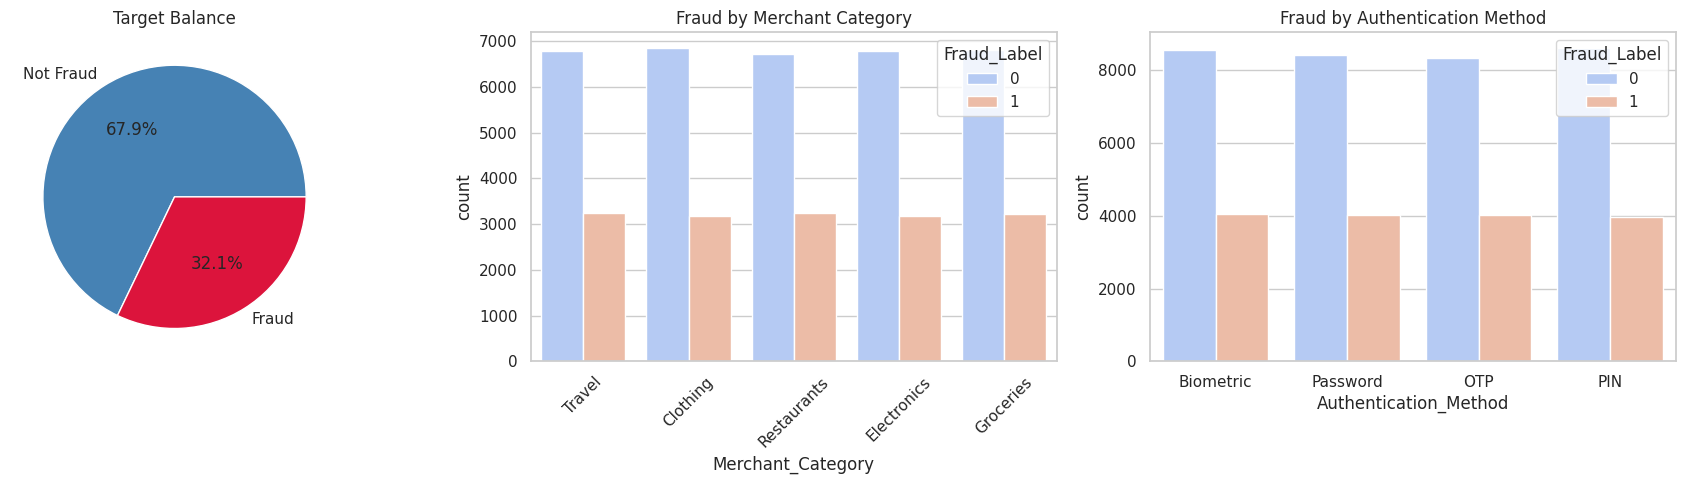

In [3]:
# Target balance plus two categorical breakdowns, grouped into one figure
# instead of scattering many separate plots.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['Fraud_Label'].value_counts().plot.pie(
    labels=['Not Fraud', 'Fraud'], autopct='%1.1f%%', colors=['steelblue', 'crimson'],
    ax=axes[0], ylabel='')
axes[0].set_title("Target Balance")

sns.countplot(x='Merchant_Category', hue='Fraud_Label', data=df, palette='coolwarm', ax=axes[1])
axes[1].set_title("Fraud by Merchant Category")
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(x='Authentication_Method', hue='Fraud_Label', data=df, palette='coolwarm', ax=axes[2])
axes[2].set_title("Fraud by Authentication Method")

plt.tight_layout()
plt.show()

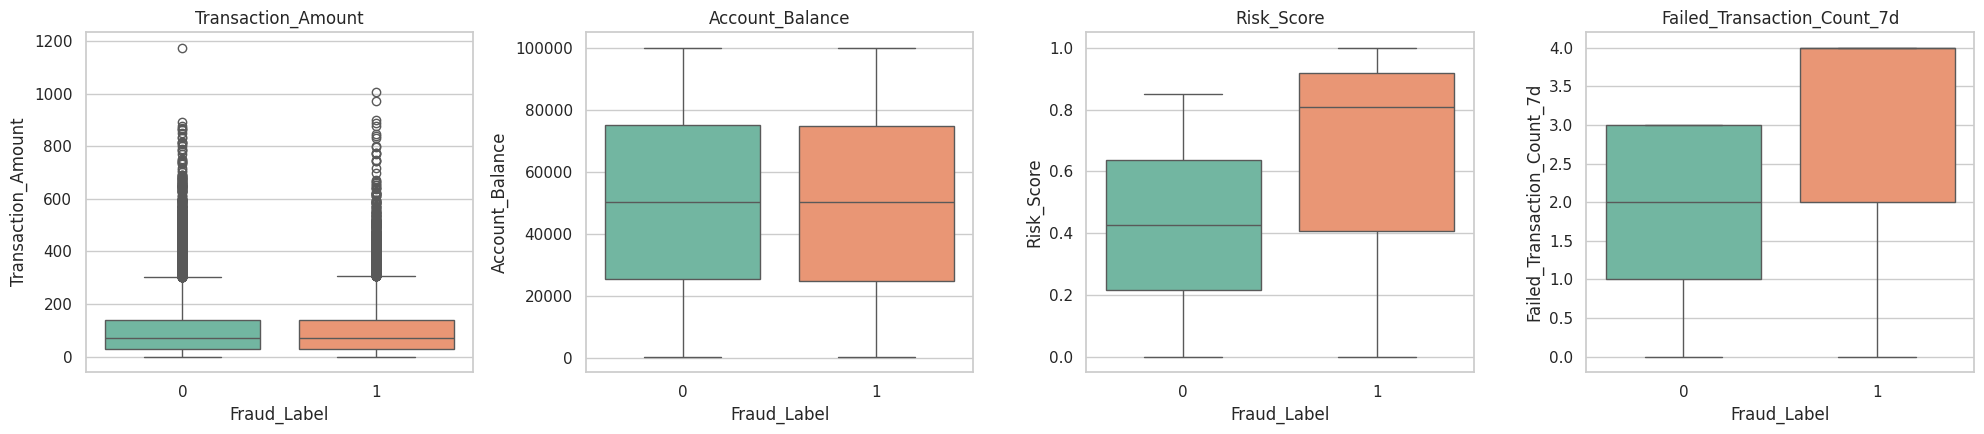

In [4]:
# Numeric feature distributions split by label: the fastest way to spot
# separation between classes before running any model.
num_cols_preview = ['Transaction_Amount', 'Account_Balance', 'Risk_Score', 'Failed_Transaction_Count_7d']
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, col in zip(axes, num_cols_preview):
    sns.boxplot(x=df['Fraud_Label'], y=df[col], hue=df['Fraud_Label'], palette='Set2', legend=False, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

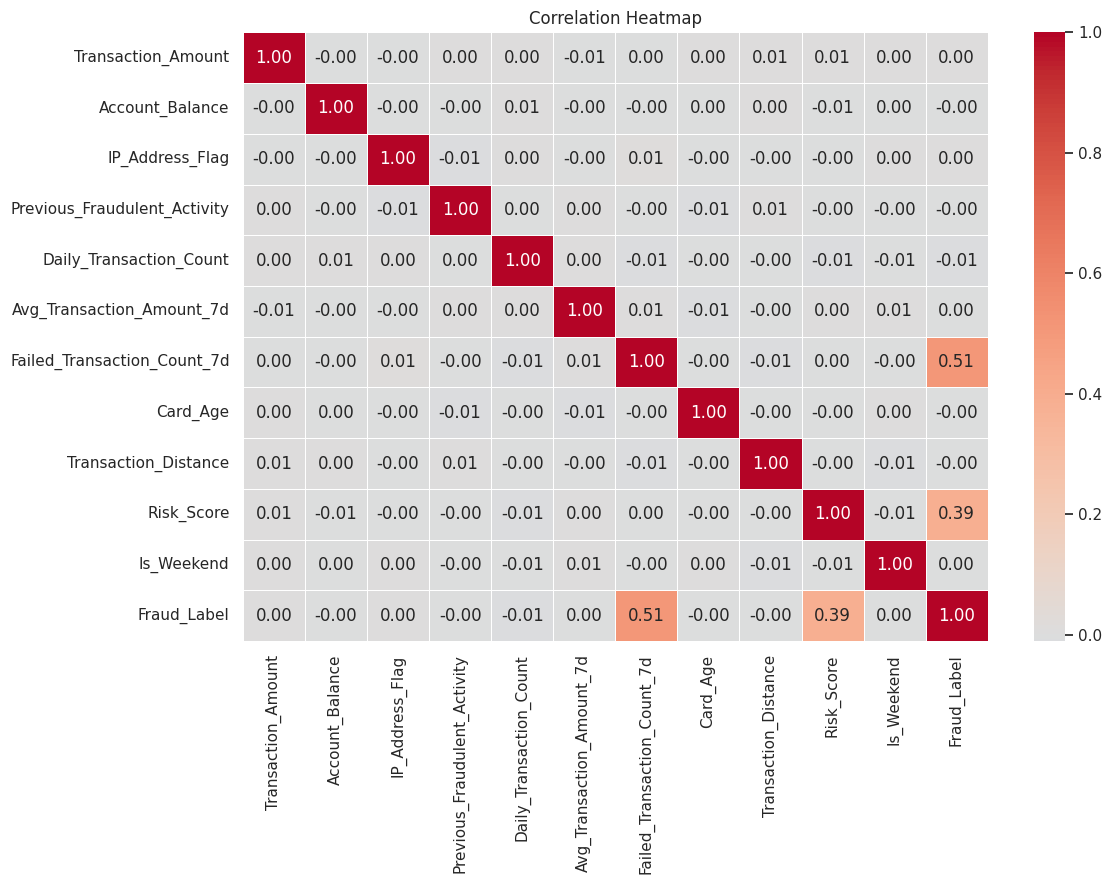

Correlation with Fraud_Label (sorted):
Fraud_Label                     1.000000
Failed_Transaction_Count_7d     0.509871
Risk_Score                      0.385810
IP_Address_Flag                 0.003028
Transaction_Amount              0.001901
Avg_Transaction_Amount_7d       0.000703
Is_Weekend                      0.000064
Transaction_Distance           -0.000116
Previous_Fraudulent_Activity   -0.000718
Card_Age                       -0.003120
Account_Balance                -0.003153
Daily_Transaction_Count        -0.007065
Name: Fraud_Label, dtype: float64


In [5]:
# Correlation heatmap: numeric features against each other and the target.
plt.figure(figsize=(12, 9))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.4, center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("Correlation with Fraud_Label (sorted):")
print(corr['Fraud_Label'].sort_values(ascending=False))

## 3. Leakage investigation

The correlation table above already singles out two features as unusually predictive on their own: `Risk_Score` and `Failed_Transaction_Count_7d`. This section checks whether they leak the label outright rather than merely correlating with it.

In [6]:
print("Fraud rate by Failed_Transaction_Count_7d:")
print(df.groupby('Failed_Transaction_Count_7d')['Fraud_Label'].mean())

# A simple two-feature rule tests whether the label is trivially recoverable.
leak_rule = ((df['Failed_Transaction_Count_7d'] == 4) | (df['Risk_Score'] > 0.85)).astype(int)
leak_rule_accuracy = (leak_rule == df['Fraud_Label']).mean()
print(f"\nAccuracy of a 2-feature hand-written rule: {leak_rule_accuracy:.4f}")

Fraud rate by Failed_Transaction_Count_7d:
Failed_Transaction_Count_7d
0    0.153984
1    0.154350
2    0.145398
3    0.156715
4    1.000000
Name: Fraud_Label, dtype: float64

Accuracy of a 2-feature hand-written rule: 1.0000


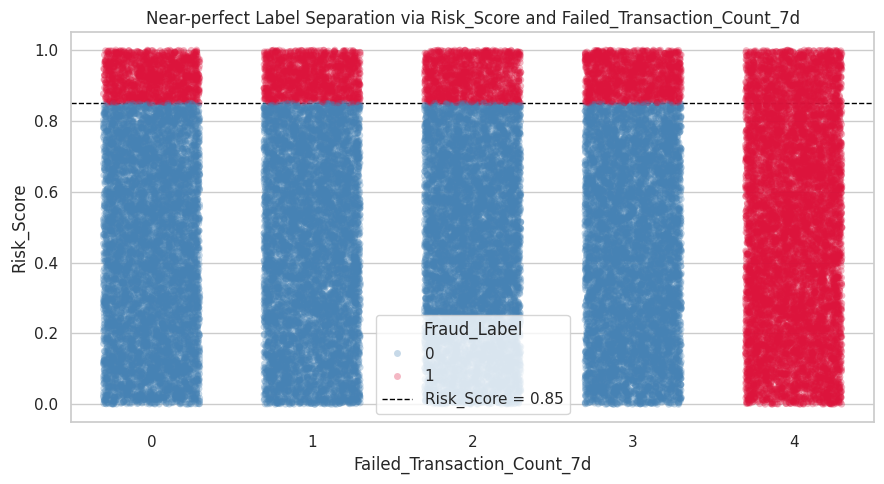

Conclusion: a hand-written rule using only 2 of 18 features reaches 100.00% accuracy. Any model given these two features is not learning fraud patterns, it is rediscovering this rule. All models below are therefore trained twice: once with the full feature set ('naive'), and once with Risk_Score and Failed_Transaction_Count_7d removed ('leakage-aware').


In [7]:
# Visualizing the same thing: fraud (red) and non-fraud (blue) points
# separate almost perfectly along Risk_Score once Failed_Transaction_Count_7d == 4
# is set aside, exactly what a tree-based model finds in a single split.
plt.figure(figsize=(9, 5))
sns.stripplot(x='Failed_Transaction_Count_7d', y='Risk_Score', hue='Fraud_Label',
              data=df, palette=['steelblue', 'crimson'], alpha=0.3, jitter=0.3)
plt.axhline(0.85, color='black', linestyle='--', linewidth=1, label='Risk_Score = 0.85')
plt.title("Near-perfect Label Separation via Risk_Score and Failed_Transaction_Count_7d")
plt.legend(title='Fraud_Label')
plt.tight_layout()
plt.show()

print(
    f"Conclusion: a hand-written rule using only 2 of 18 features reaches "
    f"{leak_rule_accuracy:.2%} accuracy. Any model given these two features "
    f"is not learning fraud patterns, it is rediscovering this rule. All "
    f"models below are therefore trained twice: once with the full feature "
    f"set ('naive'), and once with Risk_Score and Failed_Transaction_Count_7d "
    f"removed ('leakage-aware')."
)

## 4. Cleaning and feature engineering

In [8]:
# Drop identifier columns (no predictive meaning, near-unique per row).
df_model = df.drop(columns=['Transaction_ID', 'User_ID'])

# Timestamp is a near-unique string per row; label-encoding it directly would
# just assign each row an arbitrary large number. Extract the components
# that could plausibly carry signal (hour of day, day of week) instead.
ts = pd.to_datetime(df_model['Timestamp'])
df_model['Hour'] = ts.dt.hour
df_model['DayOfWeek'] = ts.dt.dayofweek
df_model = df_model.drop(columns=['Timestamp'])

y = df_model['Fraud_Label']
X_full = df_model.drop(columns=['Fraud_Label'])

LEAK_COLS = ['Risk_Score', 'Failed_Transaction_Count_7d']
X_leakage_aware = X_full.drop(columns=LEAK_COLS)

print("Naive feature set:", X_full.shape[1], "columns")
print("Leakage-aware feature set:", X_leakage_aware.shape[1], "columns")

Naive feature set: 19 columns
Leakage-aware feature set: 17 columns


## 5. Train / test split and preprocessing

In [9]:
# One shared split (by row index) is reused for both feature sets so the
# naive vs. leakage-aware comparison later is apples-to-apples.
idx_train, idx_test = train_test_split(
    X_full.index, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
y_train, y_test = y.loc[idx_train], y.loc[idx_test]


def build_preprocessor(X):
    """Numeric columns are scaled; nominal categoricals are one-hot encoded.
    Fitting happens only on the training split (below) to avoid leaking
    test-set categories or scale into preprocessing. sparse_output is pinned
    to False explicitly: mixing a dense StandardScaler output with a sparse
    OneHotEncoder output inside ColumnTransformer is version/threshold
    -dependent, and SHAP/seaborn downstream expect dense arrays."""
    num_cols = X.select_dtypes(include='number').columns.tolist()
    cat_cols = X.select_dtypes(exclude='number').columns.tolist()
    return ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ])


def make_train_test(X):
    X_train, X_test = X.loc[idx_train], X.loc[idx_test]
    pre = build_preprocessor(X)
    return pre.fit_transform(X_train), pre.transform(X_test), pre


Xtr_naive, Xte_naive, pre_naive = make_train_test(X_full)
Xtr_leak, Xte_leak, pre_leak = make_train_test(X_leakage_aware)
print("Naive processed shape:", Xtr_naive.shape)
print("Leakage-aware processed shape:", Xtr_leak.shape)

Naive processed shape: (35000, 38)
Leakage-aware processed shape: (35000, 36)


## 6. Model training and evaluation framework

In [10]:
def get_models():
    """Fresh model instances each call, since the same models are trained
    twice (naive and leakage-aware) and must not share fitted state.
    Random Forest is depth-limited for the same reason as the Decision Tree:
    left unconstrained, it grows trees averaging depth ~38 on the
    leakage-aware features (verified directly), fitting noise rather than
    signal, and this also makes exact SHAP explanation impractically slow.
    class_weight='balanced' is applied wherever a model supports it (Logistic
    Regression, Decision Tree, Random Forest, SVM); AdaBoost, Naive Bayes,
    and KNN have no such parameter in scikit-learn."""
    return {
        'Logistic Regression': LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
        'KNN': KNeighborsClassifier(),
        'Decision Tree': DecisionTreeClassifier(
            max_depth=10, min_samples_leaf=20, class_weight='balanced', random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(
            max_depth=10, min_samples_leaf=10, class_weight='balanced', random_state=RANDOM_STATE),
        'SVM': SVC(class_weight='balanced', random_state=RANDOM_STATE),
        'Naive Bayes': GaussianNB(),
        'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE),
    }


def score_of(model, X):
    """Ranking score for ROC/AUC: predicted probability where available,
    decision function otherwise (SVC without probability=True)."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


def train_and_evaluate(X_train, X_test, y_train, y_test, label):
    """Trains every model in get_models() and returns a results dict keyed
    by model name, holding the fitted model, predictions, scores, and core
    metrics (including PR-AUC alongside ROC-AUC, since PR-AUC is the more
    honest metric when the positive class is the minority)."""
    results = {}
    for name, model in get_models().items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_score = score_of(model, X_test)
        results[name] = {
            'model': model,
            'y_pred': y_pred,
            'y_score': y_score,
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, pos_label=1),
            'recall': recall_score(y_test, y_pred, pos_label=1),
            'f1': f1_score(y_test, y_pred, pos_label=1),
            'auc': roc_auc_score(y_test, y_score),
            'avg_precision': average_precision_score(y_test, y_score),
            'pipeline': label,
        }
    return results


def results_to_df(results):
    return pd.DataFrame({
        name: {k: v for k, v in r.items() if k in
               ('accuracy', 'precision', 'recall', 'f1', 'auc', 'avg_precision')}
        for name, r in results.items()
    }).T.round(4)


def plot_confusion_grid(results, y_test, title):
    n = len(results)
    fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(5 * ((n + 1) // 2), 9))
    axes = axes.ravel()
    for ax, (name, r) in zip(axes, results.items()):
        cm = confusion_matrix(y_test, r['y_pred'])
        ConfusionMatrixDisplay(cm, display_labels=['No Fraud', 'Fraud']).plot(
            ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f"{name}\n(acc={r['accuracy']:.2f})")
    for ax in axes[n:]:
        ax.axis('off')
    fig.suptitle(title, fontsize=15)
    plt.tight_layout()
    return fig


def plot_roc_comparison(results, y_test, title):
    plt.figure(figsize=(7, 6))
    for name, r in results.items():
        fpr, tpr, _ = roc_curve(y_test, r['y_score'])
        plt.plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.2f})")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(fontsize=9)
    plt.tight_layout()


def plot_pr_comparison(results, y_test, title):
    """Precision-recall curves: the more informative view than ROC when the
    positive class (fraud) is the minority and is what actually matters."""
    plt.figure(figsize=(7, 6))
    baseline = y_test.mean()
    for name, r in results.items():
        prec, rec, _ = precision_recall_curve(y_test, r['y_score'])
        plt.plot(rec, prec, label=f"{name} (AP={r['avg_precision']:.2f})")
    plt.axhline(baseline, color='k', linestyle='--', label=f'No-skill baseline ({baseline:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(title)
    plt.legend(fontsize=9)
    plt.tight_layout()

## 7. Pipeline A: naive (all features)

In [11]:
results_naive = train_and_evaluate(Xtr_naive, Xte_naive, y_train, y_test, 'Naive')
print("=== Naive (all features) results ===")
print(results_to_df(results_naive))

=== Naive (all features) results ===
                     accuracy  precision  recall      f1     auc  \
Logistic Regression    0.7961     0.6472  0.8035  0.7170  0.8942   
KNN                    0.8179     0.7908  0.5890  0.6751  0.8848   
Decision Tree          1.0000     1.0000  1.0000  1.0000  1.0000   
Random Forest          1.0000     1.0000  1.0000  1.0000  1.0000   
SVM                    0.9753     0.9330  0.9944  0.9627  0.9989   
Naive Bayes            0.8855     0.8400  0.7952  0.8170  0.9442   
AdaBoost               1.0000     1.0000  1.0000  1.0000  1.0000   

                     avg_precision  
Logistic Regression         0.8134  
KNN                         0.7374  
Decision Tree               1.0000  
Random Forest               1.0000  
SVM                         0.9978  
Naive Bayes                 0.8968  
AdaBoost                    1.0000  


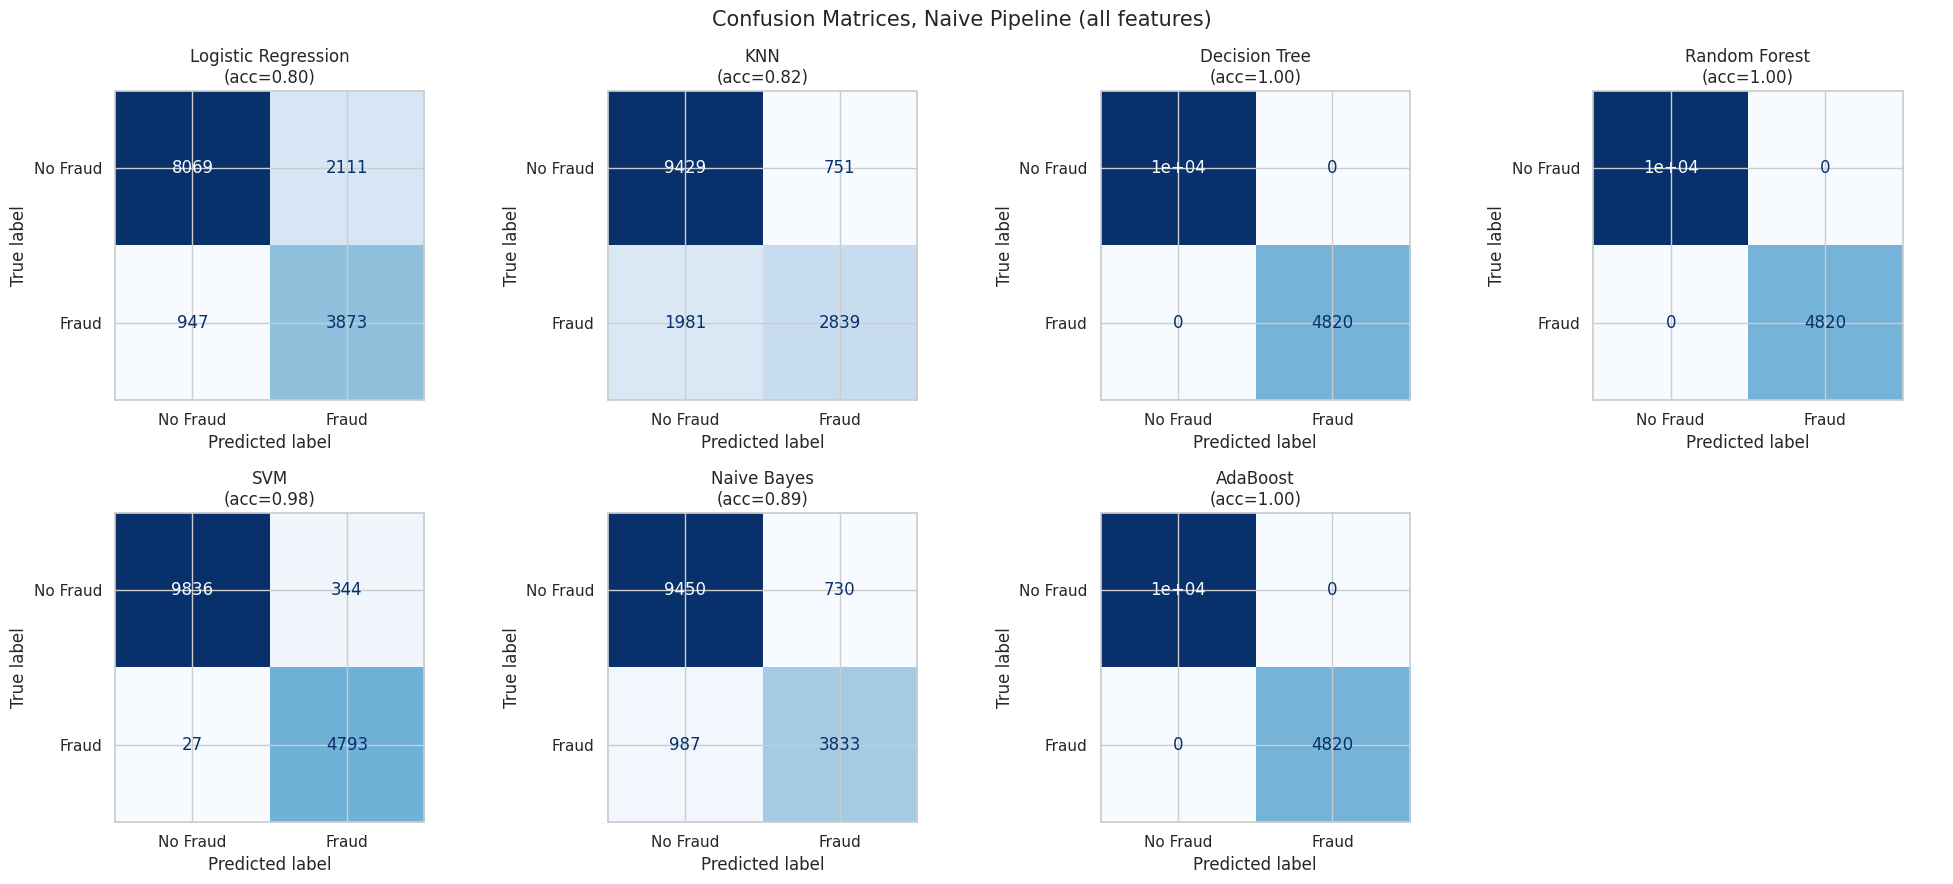

In [12]:
plot_confusion_grid(results_naive, y_test, "Confusion Matrices, Naive Pipeline (all features)")
plt.show()

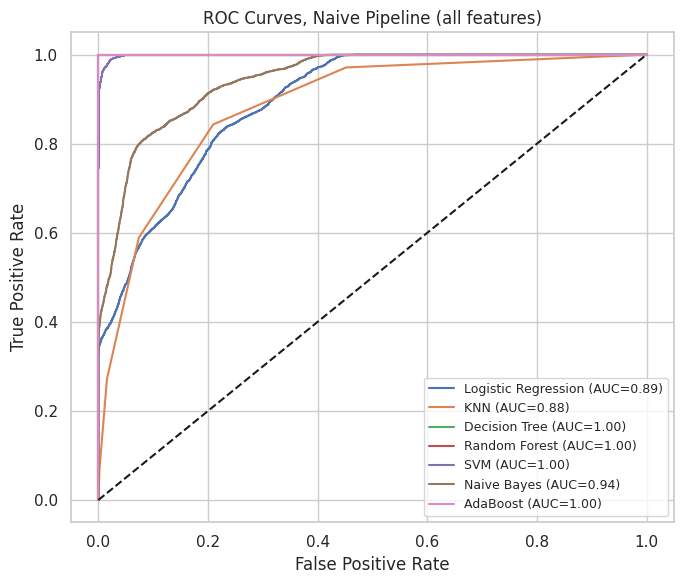

In [13]:
plot_roc_comparison(results_naive, y_test, "ROC Curves, Naive Pipeline (all features)")
plt.show()

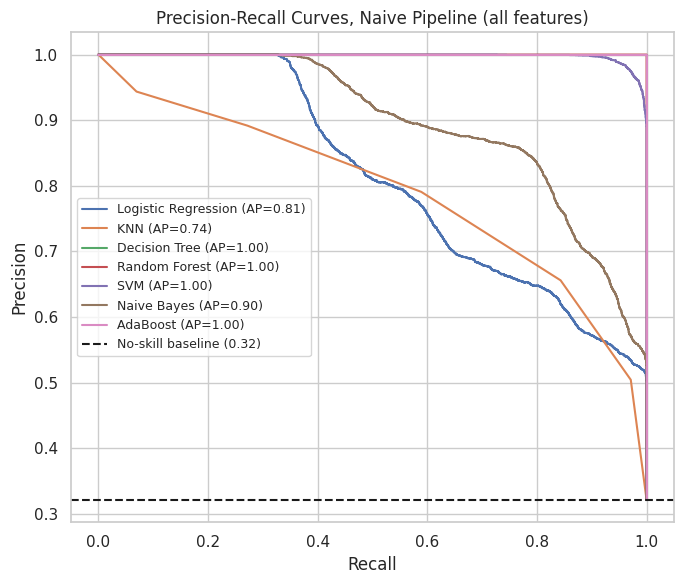

In [14]:
plot_pr_comparison(results_naive, y_test, "Precision-Recall Curves, Naive Pipeline (all features)")
plt.show()

## 8. Pipeline B: leakage-aware

In [15]:
results_leak = train_and_evaluate(Xtr_leak, Xte_leak, y_train, y_test, 'Leakage-Aware')
print("=== Leakage-aware results (Risk_Score, Failed_Transaction_Count_7d removed) ===")
print(results_to_df(results_leak))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


=== Leakage-aware results (Risk_Score, Failed_Transaction_Count_7d removed) ===
                     accuracy  precision  recall      f1     auc  \
Logistic Regression    0.5049     0.3210  0.4849  0.3863  0.4956   
KNN                    0.6120     0.3273  0.1967  0.2457  0.5059   
Decision Tree          0.4766     0.3171  0.5452  0.4010  0.4968   
Random Forest          0.5724     0.3175  0.2876  0.3018  0.4966   
SVM                    0.5085     0.3173  0.4600  0.3755  0.4932   
Naive Bayes            0.6787     0.0000  0.0000  0.0000  0.4941   
AdaBoost               0.6787     0.0000  0.0000  0.0000  0.4997   

                     avg_precision  
Logistic Regression         0.3200  
KNN                         0.3246  
Decision Tree               0.3209  
Random Forest               0.3204  
SVM                         0.3174  
Naive Bayes                 0.3203  
AdaBoost                    0.3214  


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


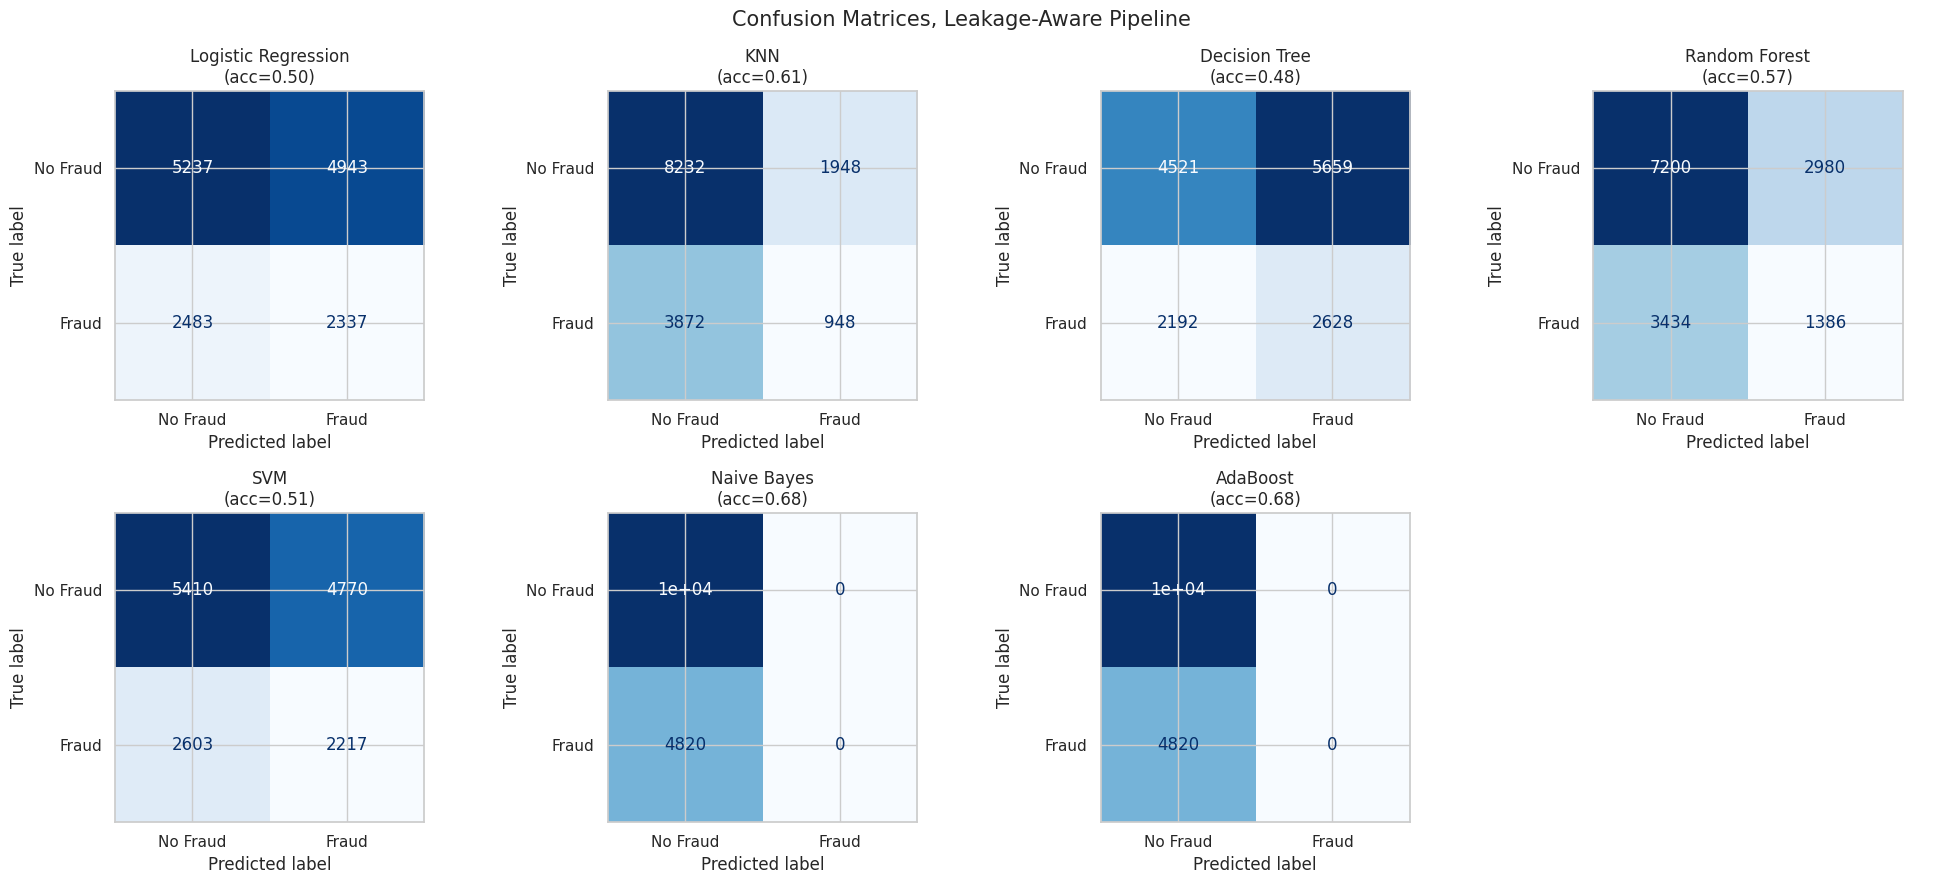

In [16]:
plot_confusion_grid(results_leak, y_test, "Confusion Matrices, Leakage-Aware Pipeline")
plt.show()

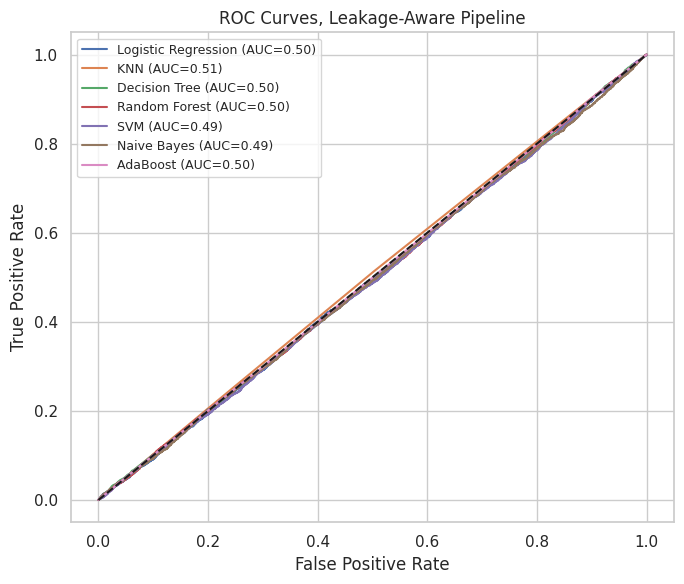

In [17]:
plot_roc_comparison(results_leak, y_test, "ROC Curves, Leakage-Aware Pipeline")
plt.show()

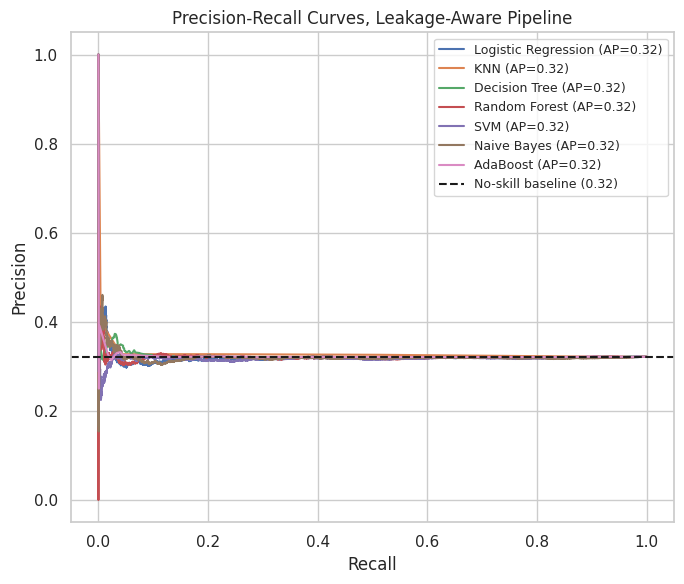

In [18]:
plot_pr_comparison(results_leak, y_test, "Precision-Recall Curves, Leakage-Aware Pipeline")
plt.show()

## 9. Naive vs. leakage-aware comparison

The single most important chart in this project: how much of each model's apparent performance was actually the leak, versus real signal. Both ROC-AUC and PR-AUC (average precision) are shown, since PR-AUC is the more honest metric here given fraud is the minority class.

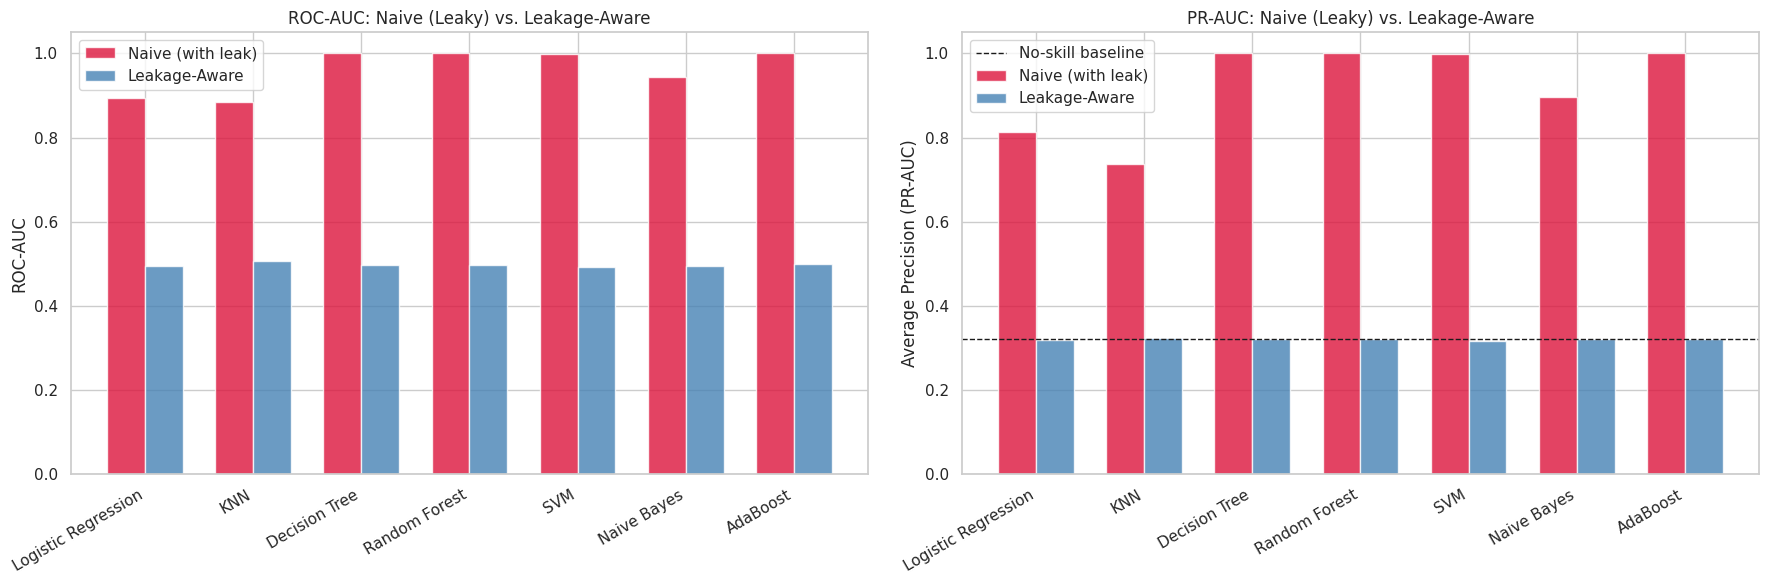

Leakage-aware ROC-AUC range across all 7 models: 0.493 to 0.506 (0.50 = chance)
Leakage-aware PR-AUC range across all 7 models:  0.317 to 0.325 (no-skill baseline = 0.321)


In [19]:
models_list = list(get_models().keys())
auc_naive = [results_naive[m]['auc'] for m in models_list]
auc_leak = [results_leak[m]['auc'] for m in models_list]
ap_naive = [results_naive[m]['avg_precision'] for m in models_list]
ap_leak = [results_leak[m]['avg_precision'] for m in models_list]

x = np.arange(len(models_list))
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(x - width / 2, auc_naive, width, label='Naive (with leak)', color='crimson', alpha=0.8)
axes[0].bar(x + width / 2, auc_leak, width, label='Leakage-Aware', color='steelblue', alpha=0.8)
axes[0].set_xticks(x, models_list, rotation=30, ha='right')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('ROC-AUC: Naive (Leaky) vs. Leakage-Aware')
axes[0].legend()

axes[1].bar(x - width / 2, ap_naive, width, label='Naive (with leak)', color='crimson', alpha=0.8)
axes[1].bar(x + width / 2, ap_leak, width, label='Leakage-Aware', color='steelblue', alpha=0.8)
axes[1].axhline(y_test.mean(), color='k', linestyle='--', linewidth=1, label='No-skill baseline')
axes[1].set_xticks(x, models_list, rotation=30, ha='right')
axes[1].set_ylabel('Average Precision (PR-AUC)')
axes[1].set_title('PR-AUC: Naive (Leaky) vs. Leakage-Aware')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Leakage-aware ROC-AUC range across all 7 models: {min(auc_leak):.3f} to {max(auc_leak):.3f} (0.50 = chance)")
print(f"Leakage-aware PR-AUC range across all 7 models:  {min(ap_leak):.3f} to {max(ap_leak):.3f} "
      f"(no-skill baseline = {y_test.mean():.3f})")

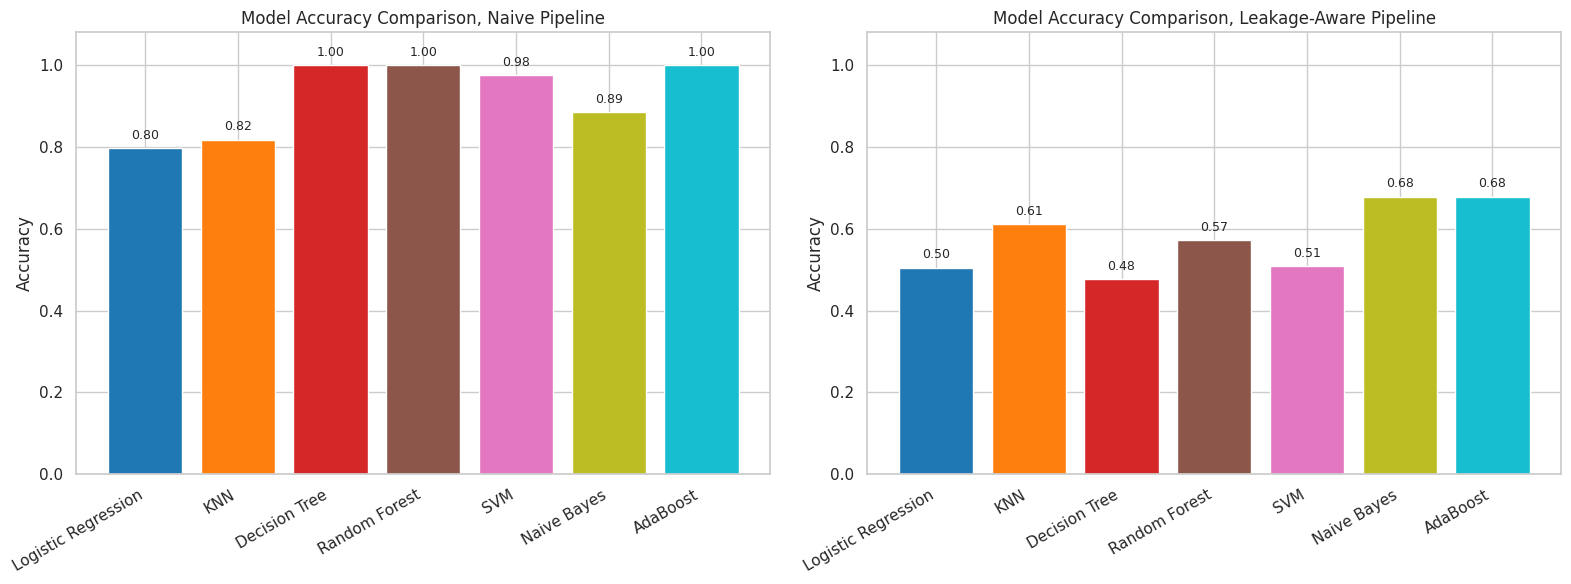

In [20]:
# Accuracy specifically, one uniquely-colored bar per model, side by side for
# each pipeline. Simpler companion to the AUC/PR-AUC view above: easier to
# read at a glance, at the cost of being the metric most distorted by class
# imbalance.
model_colors = plt.cm.tab10(np.linspace(0, 1, len(models_list)))


def plot_accuracy_bars(results, title, ax):
    accs = [results[m]['accuracy'] for m in models_list]
    bars = ax.bar(models_list, accs, color=model_colors)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.set_xticks(range(len(models_list)))
    ax.set_xticklabels(models_list, rotation=30, ha='right')
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                f'{acc:.2f}', ha='center', va='bottom', fontsize=9)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_accuracy_bars(results_naive, 'Model Accuracy Comparison, Naive Pipeline', axes[0])
plot_accuracy_bars(results_leak, 'Model Accuracy Comparison, Leakage-Aware Pipeline', axes[1])
plt.tight_layout()
plt.show()

## 10. Cost-sensitive threshold optimization

Every leakage-aware model above sits at ROC-AUC ~0.50 and PR-AUC near the no-skill baseline: no better than chance. To demonstrate the cost-sensitive thresholding methodology on a model with genuine graded, learnable signal, this section starts with the **naive pipeline's Logistic Regression**. Unlike the tree ensembles (which reach a near-perfect, step-function-like separation and leave nothing to tune), Logistic Regression cannot fully represent the two-feature rule and so produces smooth, spread-out probabilities, exactly the situation threshold-tuning is meant for.

**But that dollar figure alone would be misleading**: Logistic Regression here still has access to the two leak-derived features, so its apparent savings are not a trustworthy deployment estimate. To check this honestly, the identical sweep is repeated on the **leakage-aware** Logistic Regression (no access to the leak at all), so the naive result can be judged against a model that never saw the shortcut.

In [21]:
best_model_name = 'Logistic Regression'
best_result = results_naive[best_model_name]
y_scores = best_result['y_score']
amounts_test = X_full.loc[idx_test, 'Transaction_Amount'].values

# Cost model: a missed fraud (false negative) costs the transaction's own
# dollar amount; a false alarm (false positive) costs a flat operational
# review fee. The default 0.5 threshold is not necessarily cost-optimal.
FP_COST = 5.0

thresholds = np.linspace(0.01, 0.99, 99)
total_costs = []
for t in thresholds:
    pred_t = (y_scores >= t).astype(int)
    fn_mask = (y_test.values == 1) & (pred_t == 0)
    fp_mask = (y_test.values == 0) & (pred_t == 1)
    cost = amounts_test[fn_mask].sum() + FP_COST * fp_mask.sum()
    total_costs.append(cost)

optimal_idx = int(np.argmin(total_costs))
optimal_threshold = thresholds[optimal_idx]
cost_at_optimal = total_costs[optimal_idx]
cost_at_default = total_costs[int(np.argmin(np.abs(thresholds - 0.5)))]

print(f"Cost at default threshold (0.50):        ${cost_at_default:,.2f}")
print(f"Cost at optimal threshold ({optimal_threshold:.2f}):       ${cost_at_optimal:,.2f}")
print(f"Savings from re-tuning the threshold:     ${cost_at_default - cost_at_optimal:,.2f}")
print(
    "CAVEAT: this dollar figure demonstrates the thresholding METHOD only. "
    "It is not a trustworthy deployment estimate, since Logistic Regression "
    "here still has access to the two leak-derived features."
)

Cost at default threshold (0.50):        $108,355.62
Cost at optimal threshold (0.18):       $23,651.86
Savings from re-tuning the threshold:     $84,703.76
CAVEAT: this dollar figure demonstrates the thresholding METHOD only. It is not a trustworthy deployment estimate, since Logistic Regression here still has access to the two leak-derived features.


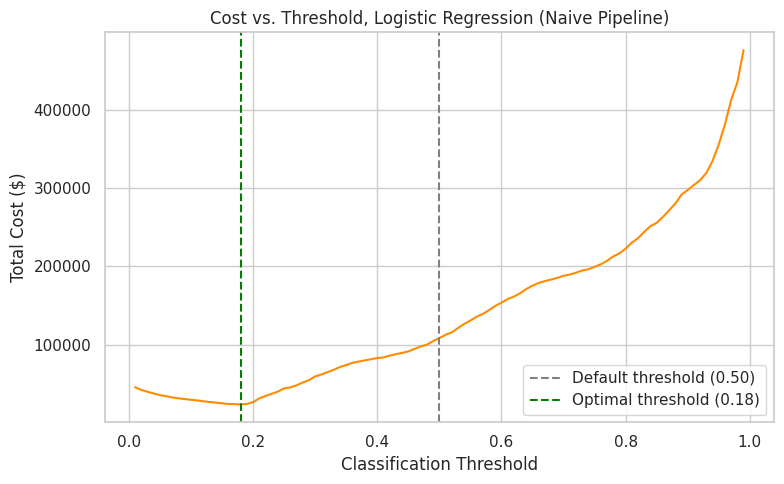

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(thresholds, total_costs, color='darkorange')
plt.axvline(0.5, color='gray', linestyle='--', label='Default threshold (0.50)')
plt.axvline(optimal_threshold, color='green', linestyle='--',
            label=f'Optimal threshold ({optimal_threshold:.2f})')
plt.xlabel('Classification Threshold')
plt.ylabel('Total Cost ($)')
plt.title(f'Cost vs. Threshold, {best_model_name} (Naive Pipeline)')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# The caveat above is worth proving, not just stating: repeat the identical
# sweep on the leakage-aware Logistic Regression (no access to the two leak
# features at all).
y_scores_leak = results_leak['Logistic Regression']['y_score']
total_costs_leak = []
for t in thresholds:
    pred_t = (y_scores_leak >= t).astype(int)
    fn_mask = (y_test.values == 1) & (pred_t == 0)
    fp_mask = (y_test.values == 0) & (pred_t == 1)
    cost = amounts_test[fn_mask].sum() + FP_COST * fp_mask.sum()
    total_costs_leak.append(cost)

optimal_idx_leak = int(np.argmin(total_costs_leak))
pred_leak_at_optimal = (y_scores_leak >= thresholds[optimal_idx_leak]).astype(int)
flag_rate_leak = pred_leak_at_optimal.mean()
print(f"Same sweep, Logistic Regression (leakage-aware): "
      f"optimal threshold {thresholds[optimal_idx_leak]:.2f}, "
      f"cost ${total_costs_leak[optimal_idx_leak]:,.2f} vs. default "
      f"${total_costs_leak[int(np.argmin(np.abs(thresholds - 0.5)))]:,.2f}")
print(
    f"Note: at that 'optimal' threshold, the leakage-aware model flags "
    f"{flag_rate_leak:.1%} of all transactions as fraud. With a near-chance "
    f"model and false-negative cost (real dollar amounts) far exceeding the "
    f"flat $5 false-positive cost, the cost-minimizing policy degenerates to "
    f"'flag almost everyone' rather than genuine discrimination, a different "
    f"failure mode than the naive model's inflated savings, but still not a "
    f"usable fraud policy: it is brute-force review, not detection."
)

Same sweep, Logistic Regression (leakage-aware): optimal threshold 0.01, cost $50,900.00 vs. default $266,410.18
Note: at that 'optimal' threshold, the leakage-aware model flags 100.0% of all transactions as fraud. With a near-chance model and false-negative cost (real dollar amounts) far exceeding the flat $5 false-positive cost, the cost-minimizing policy degenerates to 'flag almost everyone' rather than genuine discrimination, a different failure mode than the naive model's inflated savings, but still not a usable fraud policy: it is brute-force review, not detection.


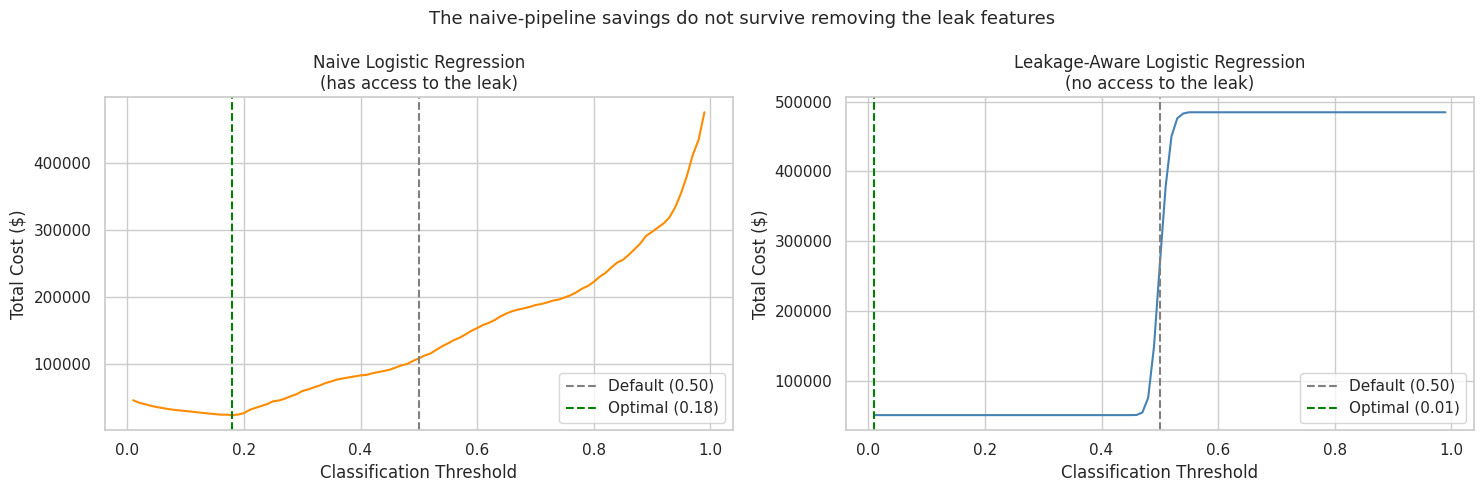

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(thresholds, total_costs, color='darkorange')
axes[0].axvline(0.5, color='gray', linestyle='--', label='Default (0.50)')
axes[0].axvline(optimal_threshold, color='green', linestyle='--',
                label=f'Optimal ({optimal_threshold:.2f})')
axes[0].set_title('Naive Logistic Regression\n(has access to the leak)')
axes[0].set_xlabel('Classification Threshold')
axes[0].set_ylabel('Total Cost ($)')
axes[0].legend()

axes[1].plot(thresholds, total_costs_leak, color='steelblue')
axes[1].axvline(0.5, color='gray', linestyle='--', label='Default (0.50)')
axes[1].axvline(thresholds[optimal_idx_leak], color='green', linestyle='--',
                label=f'Optimal ({thresholds[optimal_idx_leak]:.2f})')
axes[1].set_title('Leakage-Aware Logistic Regression\n(no access to the leak)')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('Total Cost ($)')
axes[1].legend()

fig.suptitle('The naive-pipeline savings do not survive removing the leak features', fontsize=13)
plt.tight_layout()
plt.show()

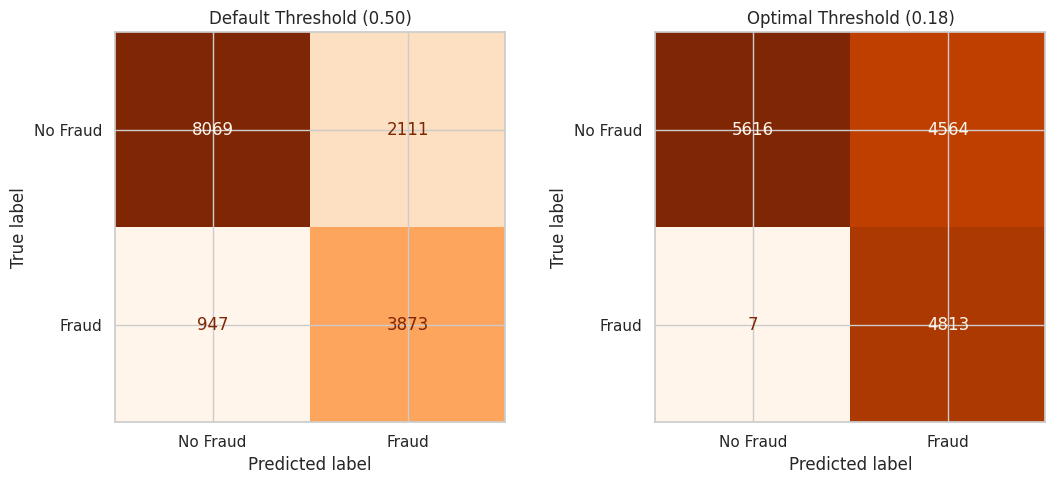

In [25]:
# Confusion matrices at default vs. optimal threshold (naive model), side by side.
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, t, title in [(axes[0], 0.5, 'Default Threshold (0.50)'),
                      (axes[1], optimal_threshold, f'Optimal Threshold ({optimal_threshold:.2f})')]:
    pred_t = (y_scores >= t).astype(int)
    cm = confusion_matrix(y_test, pred_t)
    ConfusionMatrixDisplay(cm, display_labels=['No Fraud', 'Fraud']).plot(ax=ax, cmap='Oranges', colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 11. Explainability with SHAP

Random Forest is used for SHAP regardless of which model scored best above, since `TreeExplainer` is fast and exact for tree ensembles. Two versions are shown side by side: naive (to visually confirm the leak) and leakage-aware (to see what, if anything, drives predictions once it's removed).

In [26]:
rf_naive = results_naive['Random Forest']['model']
rf_leak = results_leak['Random Forest']['model']

feature_names_naive = pre_naive.get_feature_names_out()
feature_names_leak = pre_leak.get_feature_names_out()

# TreeExplainer is exact but still scales with the number of rows explained;
# a random 1,000-row sample of the test set is standard practice for a
# summary plot and keeps runtime reasonable without changing the conclusion.
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(Xte_naive.shape[0], size=min(1000, Xte_naive.shape[0]), replace=False)
Xte_naive_sample = Xte_naive[sample_idx]
Xte_leak_sample = Xte_leak[sample_idx]


def compute_shap_values(model, X_sample):
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_sample, check_additivity=False)
    if isinstance(sv, list):
        sv = sv[1]
    elif sv.ndim == 3:
        sv = sv[:, :, 1]
    return sv


shap_values_naive = compute_shap_values(rf_naive, Xte_naive_sample)
shap_values_leak = compute_shap_values(rf_leak, Xte_leak_sample)
print("SHAP values computed for both pipelines.")

SHAP values computed for both pipelines.


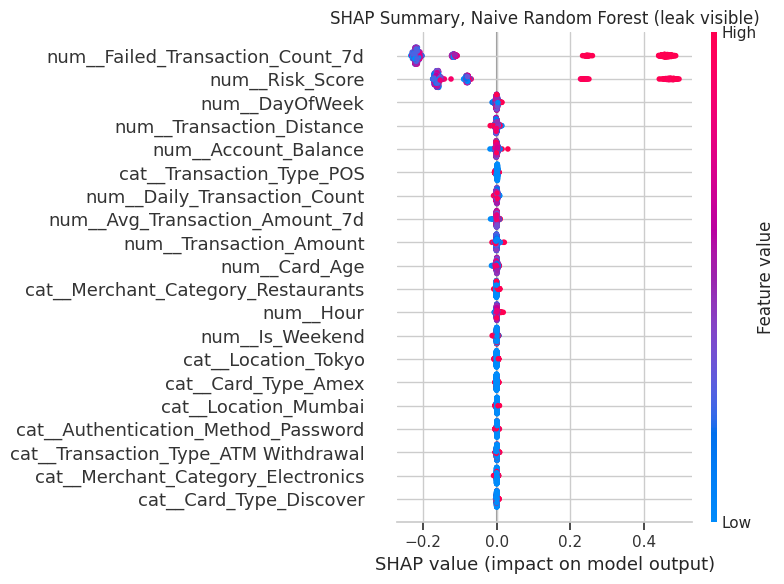

In [27]:
shap.summary_plot(shap_values_naive, Xte_naive_sample, feature_names=feature_names_naive,
                   show=False, plot_size=(8, 6))
plt.title("SHAP Summary, Naive Random Forest (leak visible)")
plt.tight_layout()
plt.show()

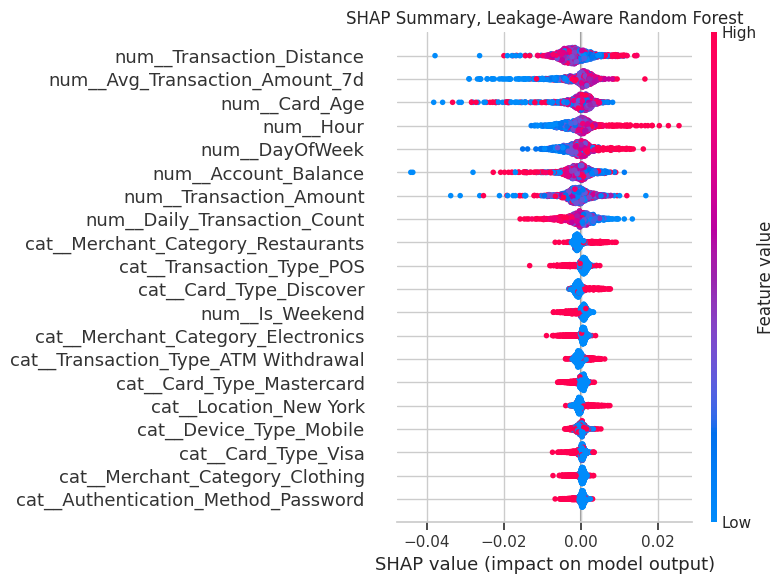

In [28]:
shap.summary_plot(shap_values_leak, Xte_leak_sample, feature_names=feature_names_leak,
                   show=False, plot_size=(8, 6))
plt.title("SHAP Summary, Leakage-Aware Random Forest")
plt.tight_layout()
plt.show()

## 12. All-models, all-metrics comparison

One consolidated view of every model against every metric, for each pipeline. A heatmap is used instead of a 42-bar grouped bar chart (7 models x 6 metrics), since it stays readable at this size and the color scale makes the naive-vs-leakage-aware contrast immediately visible.

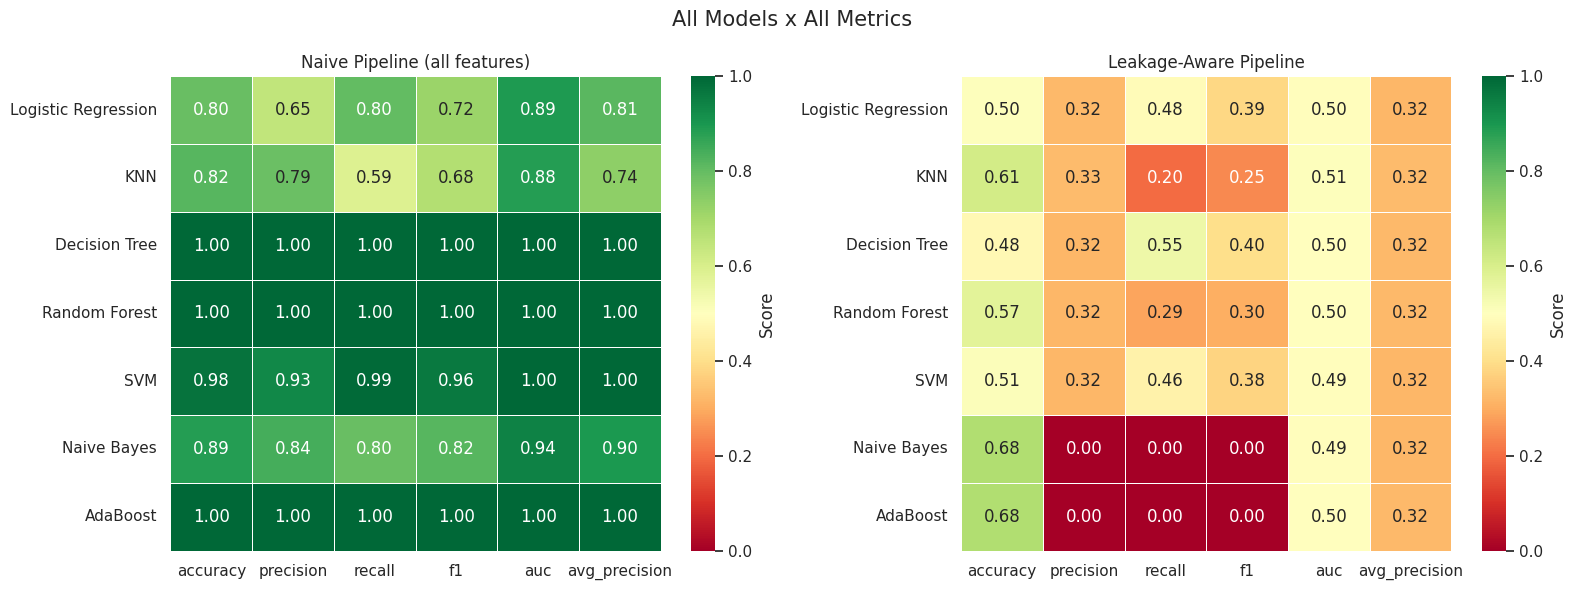

In [29]:
metrics_cols = ['accuracy', 'precision', 'recall', 'f1', 'auc', 'avg_precision']
naive_matrix = results_to_df(results_naive)[metrics_cols]
leak_matrix = results_to_df(results_leak)[metrics_cols]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(naive_matrix, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Score'}, ax=axes[0])
axes[0].set_title("Naive Pipeline (all features)")

sns.heatmap(leak_matrix, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Score'}, ax=axes[1])
axes[1].set_title("Leakage-Aware Pipeline")

fig.suptitle("All Models x All Metrics", fontsize=15)
plt.tight_layout()
plt.show()

## 13. Summary

In [30]:
print("=== Summary ===")
print(f"Naive pipeline best ROC-AUC:      {max(auc_naive):.4f} ({models_list[int(np.argmax(auc_naive))]})")
print(f"Leakage-aware best ROC-AUC:       {max(auc_leak):.4f} ({models_list[int(np.argmax(auc_leak))]}, essentially chance level)")
print(f"Leakage-aware best PR-AUC:        {max(ap_leak):.4f} (no-skill baseline = {y_test.mean():.4f})")
print(f"Cost-optimal threshold (naive Logistic Regression): {optimal_threshold:.2f} (vs. default 0.50)")
print(f"Illustrative cost reduction (methodology demo, not a deployment estimate): ${cost_at_default - cost_at_optimal:,.2f}")
print(
    "\nHeadline finding: near-perfect naive accuracy is entirely explained by "
    "two leaking features. Once removed, no model beats random guessing on "
    "either ROC-AUC or PR-AUC, and even the cost-sensitive threshold analysis "
    "does not recover a usable policy from the leakage-aware model, it just "
    "degenerates to flagging almost everyone. This synthetic dataset does not "
    "contain a realistic fraud detection problem outside of the leak."
)

=== Summary ===
Naive pipeline best ROC-AUC:      1.0000 (Decision Tree)
Leakage-aware best ROC-AUC:       0.5059 (KNN, essentially chance level)
Leakage-aware best PR-AUC:        0.3246 (no-skill baseline = 0.3213)
Cost-optimal threshold (naive Logistic Regression): 0.18 (vs. default 0.50)
Illustrative cost reduction (methodology demo, not a deployment estimate): $84,703.76

Headline finding: near-perfect naive accuracy is entirely explained by two leaking features. Once removed, no model beats random guessing on either ROC-AUC or PR-AUC, and even the cost-sensitive threshold analysis does not recover a usable policy from the leakage-aware model, it just degenerates to flagging almost everyone. This synthetic dataset does not contain a realistic fraud detection problem outside of the leak.
